## Solo Project 

Authors: Sofia Rashidi

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import os 
from astropy.io import ascii 
from scipy import optimize
from scipy.optimize import curve_fit 

imports the data and creates the sine wave model

In [5]:
path = ("/Users/sofia/Downloads/UID_0043587_RVC_008.tbl.txt")

In [7]:
ascii_data = ascii.read(path)

     HJD      Radial_Velocity Radial_Velocity_Uncertainty
     days          m / s                 m / s           
------------- --------------- ---------------------------
 2449676.0632   131.910003662                   4.8400002
2449767.77441   22.6000003815                   2.5699999
2449768.83203  -5.48999977112                   2.6800001
2449793.79785   107.309997559                        1.52
2450056.98828   116.669998169                   1.6199999
2450087.88184   77.2600021362                   2.1600001
2450088.91894   32.5999984741                        1.64
2450089.00586   33.7299995422                   1.5599999
2450089.77637   2.73000001907                        1.61
          ...             ...                         ...
2455576.88561   51.4900016785                   1.2999998
2455577.86121   72.4700012207                        1.02
2455578.76532   97.7200012207                        1.88
2455578.86419   102.930000305                        1.03
 2455582.8289 

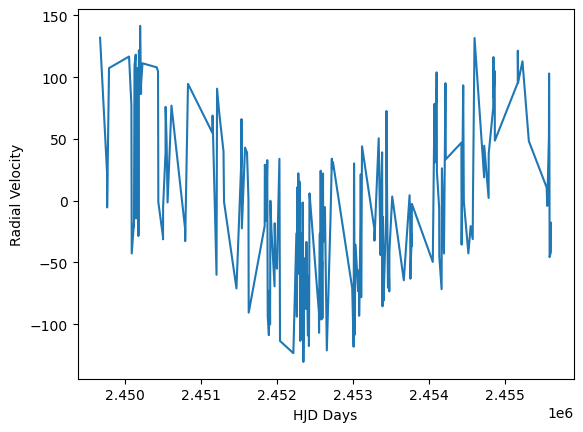

In [32]:
print(ascii_data)

HJD_days = ascii_data['HJD'] 
radial_velocity = ascii_data['Radial_Velocity']
uncertainty = ascii_data['Radial_Velocity_Uncertainty']

plt.plot(HJD_days, radial_velocity)
plt.xlabel("HJD Days")
plt.ylabel("Radial Velocity")


def model(x,a,b,c,d):
    return a * np.sin(2* np.pi * (x-b) / c) + d




In [33]:
guess = [140, 30, 7000, np.mean(radial_velocity)]
modeled, _ = curve_fit(model, HJD_days, radial_velocity, p0=guess, sigma=uncertainty) 

In [34]:
corrected_a = modeled[0]
corrected_b = modeled[1]
corrected_c = modeled[2]
corrected_d = modeled[3]

In [36]:
print("Amp: ", corrected_a) 
print("Shift: ", corrected_b)
print("Period: ", corrected_c)
print("offset: ", corrected_d)

Amp:  -47.91744867354689
Shift:  769021.8098914939
Period:  4807.064623728754
offset:  -1.4183196666791367


In [39]:
days_fake_data = np.linspace(np.min(HJD_days), np.max(HJD_days), 274)
radial_fit = model(days_fake_data, corrected_a, corrected_b, corrected_c, corrected_d)

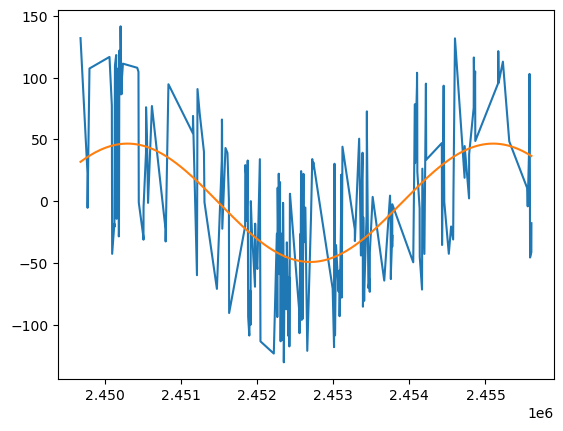

In [60]:
plt.plot(HJD_days, radial_velocity, label='radial velocity')
plt.plot(days_fake_data, radial_fit, label='model')

plots and defines the residuals

In [49]:
radial_velocity_model = model(HJD_days, *modeled)
residuals = radial_velocity - radial_velocity_model

(array([ 3.,  4.,  2.,  1.,  4.,  6.,  6.,  3.,  4.,  3.,  8.,  3.,  6.,
         4.,  4., 13.,  7.,  6.,  2.,  1.,  1.,  6.,  4.,  3.,  1.,  7.,
         4.,  5.,  5.,  3.,  4.,  2.,  1.,  5.,  5.,  3.,  4.,  4.,  6.,
         5.,  2.,  0.,  4.,  1.,  4.,  6.,  3.,  4.,  3.,  1.,  7.,  7.,
         2.,  5.,  5.,  5.,  8.,  6.,  6.,  5.,  6.,  2.,  2.,  4.,  2.,
         0.,  2.,  2.,  0.,  2.]),
 array([-87.60992438, -84.9157796 , -82.22163483, -79.52749005,
        -76.83334527, -74.13920049, -71.44505571, -68.75091093,
        -66.05676615, -63.36262137, -60.66847659, -57.97433181,
        -55.28018703, -52.58604225, -49.89189747, -47.19775269,
        -44.50360791, -41.80946313, -39.11531835, -36.42117357,
        -33.72702879, -31.03288401, -28.33873923, -25.64459445,
        -22.95044968, -20.2563049 , -17.56216012, -14.86801534,
        -12.17387056,  -9.47972578,  -6.785581  ,  -4.09143622,
         -1.39729144,   1.29685334,   3.99099812,   6.6851429 ,
          9.37928768,  1

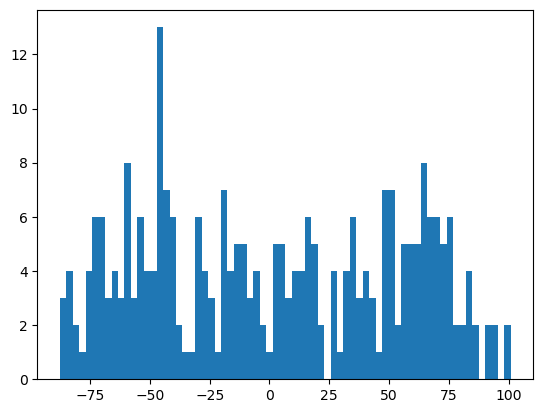

In [62]:
plt.hist(residuals, bins=70)

this defines the std for residuals

In [56]:
std_residuals = np.std(residuals)
mean_uncertainty = np.mean(uncertainty)
print("std of residuals: ", std_residuals)
print("mean of uncertainty: ", mean_uncertainty)


M = 0.905

k = corrected_a 
p = corrected_c 

planet = (k/28.43) * (p/365)**(1/3) * (M)**(2/3)


std of residuals:  52.21206735305716
mean of uncertainty:  1.8060667343065693


In [61]:
print("Planet Mass in Jupiters: ", planet)

Planet Mass in Jupiters:  -3.72401634238068


In [58]:
print("period: ", p)

period:  4807.064623728754


I think its 55 cnc (d) because of the period of days